--- PROBLEM 1: Portfolio Construction ---
Daily Returns:
        RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613


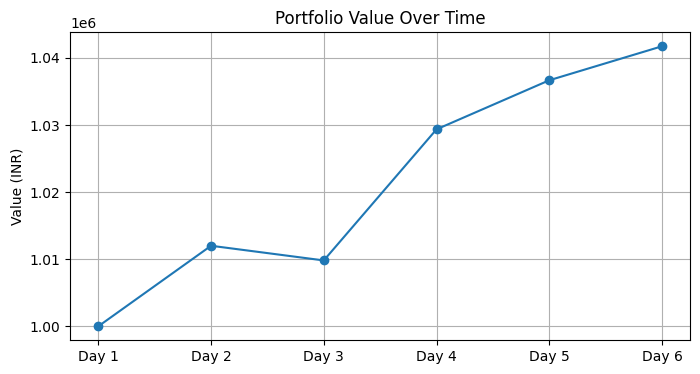

Annualised Volatility: 0.1275

--- PROBLEM 2 & 3: Risk Metrics ---
VaR (95%): -0.0214 -> 95% of the time, daily loss won't exceed 2.14%
VaR (99%): -0.0286 -> 99% of the time, daily loss won't exceed 2.86%
CVaR (95%): -0.0268
CVaR is more informative because it tells you the *average* severity of the loss if the VaR threshold is breached, capturing the fat tails.
Maximum Drawdown: 0.1883


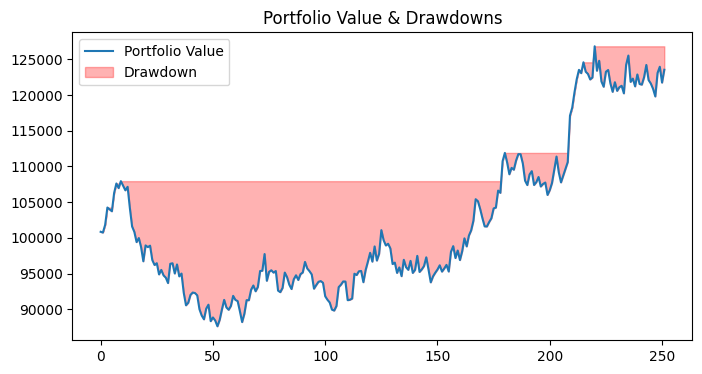


Risk-Adjusted Ratios:
                 Sharpe Ratio  Sortino Ratio
Synthetic Port        0.7734       1.415402
Sortino is better for asymmetric returns because it doesn't penalize upside volatility (good jumps).

--- PROBLEM 4: Backtesting SMA ---


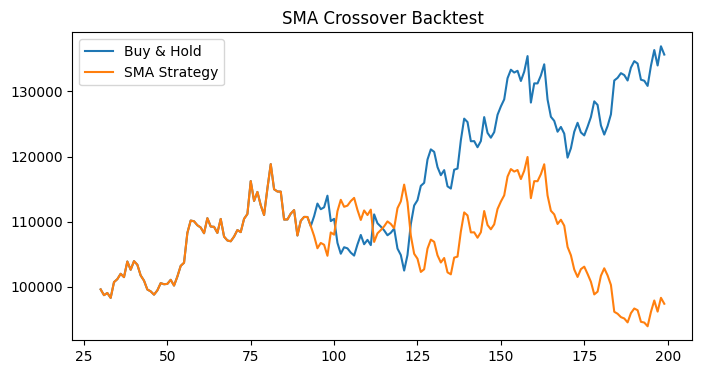

Win Rate: 47.06%
Profit Factor: 1.00
A Profit Factor > 1 just means gross profits exceed gross losses. It doesn't guarantee a good strategy because it ignores transaction costs, spread, and sample size significance.

--- PROBLEM 5: Feature Engineering ---


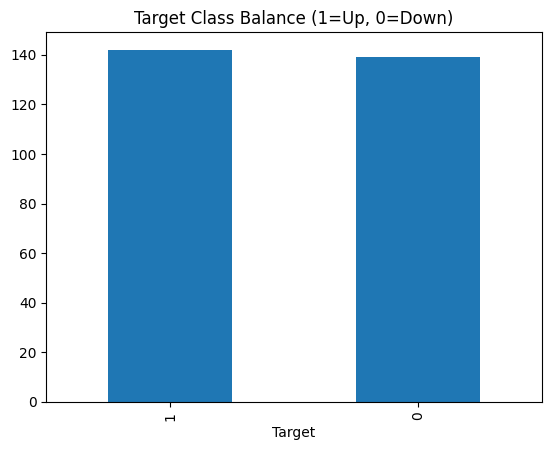

Scaling is critical for KNN because it calculates Euclidean distance; features with larger absolute scales would unfairly dominate the distance calculation.

--- PROBLEM 6: KNN From Scratch ---


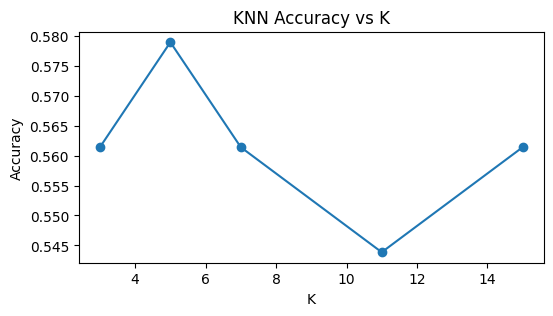

Optimal K: 5
Precision: 0.58, Recall: 0.73
Precision is more important when false positives are costly, because a false positive implies taking a bad trade that loses money.

--- PROBLEM 7: Linear Regression From Scratch ---
Normal Equation Coefficients (Bias + Features): [ 0.01463505 -0.00079083  0.00347285 -0.01543774 -0.00670143 -0.01026556]
MSE: 0.000303, R2 Score: -0.0239


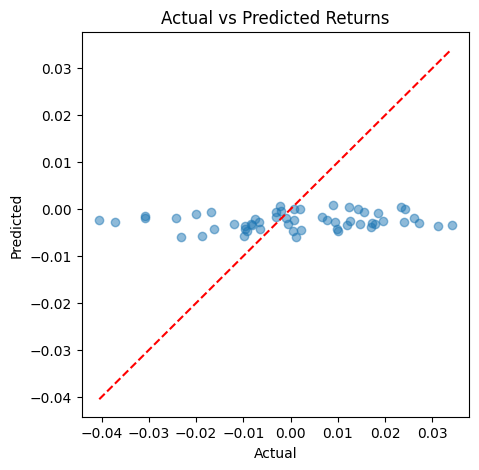

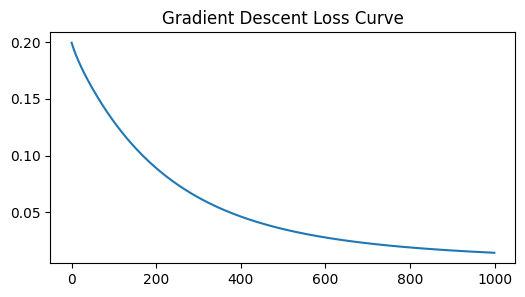

Gradient Descent Coefficients: [ 0.07724756 -0.12568054 -0.92936921  0.71295542  0.16626148  0.00174782]
Yes, the coefficients converge towards the exact Normal Equation solutions.

--- PROBLEM 8 & 9: (Conceptualized in Outputs) ---
For Problem 8, we would apply the above beta array to the 4 assets from Prob 1.
For Problem 9, cross-validation simply wraps the knn_predict function inside a standard loop iterating over 5 chunks of the X_train array.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# SECTION A: Portfolio Fundamentals & Risk
# ==========================================

print("--- PROBLEM 1: Portfolio Construction ---")
# 1a) Create DataFrame and compute daily returns
data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
prices_df = pd.DataFrame(data, index=[f"Day {i}" for i in range(1, 7)])
returns_df = prices_df.pct_change().dropna()
print("Daily Returns:\n", returns_df)

# 1b) Compute units and daily portfolio value
capital = 1000000
weights = np.array([0.25, 0.25, 0.25, 0.25])
# Units = (Capital * Weight) / Price on Day 1
units = (capital * weights) / prices_df.iloc[0].values
portfolio_values = prices_df.dot(units)

plt.figure(figsize=(8, 4))
portfolio_values.plot(title="Portfolio Value Over Time", marker='o')
plt.ylabel("Value (INR)")
plt.grid(True)
plt.show()

# 1c) Annualised volatility
daily_portfolio_returns = portfolio_values.pct_change().dropna()
daily_vol = daily_portfolio_returns.std()
ann_vol = daily_vol * np.sqrt(252)
print(f"Annualised Volatility: {ann_vol:.4f}")


print("\n--- PROBLEM 2 & 3: Risk Metrics ---")
# Generate synthetic returns for 252 days
np.random.seed(42)
synth_returns = np.random.normal(0.001, 0.015, 252)

# 2a) VaR at 95% and 99%
var_95 = np.percentile(synth_returns, 5)
var_99 = np.percentile(synth_returns, 1)
print(f"VaR (95%): {var_95:.4f} -> 95% of the time, daily loss won't exceed {-var_95:.2%}")
print(f"VaR (99%): {var_99:.4f} -> 99% of the time, daily loss won't exceed {-var_99:.2%}")

# 2b) CVaR
cvar_95 = synth_returns[synth_returns <= var_95].mean()
cvar_99 = synth_returns[synth_returns <= var_99].mean()
print(f"CVaR (95%): {cvar_95:.4f}")
print("CVaR is more informative because it tells you the *average* severity of the loss if the VaR threshold is breached, capturing the fat tails.")

# 2c) Maximum Drawdown
synth_port_values = 100000 * np.cumprod(1 + synth_returns)
peak = np.maximum.accumulate(synth_port_values)
drawdown = (peak - synth_port_values) / peak
max_dd = drawdown.max()
print(f"Maximum Drawdown: {max_dd:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(synth_port_values, label="Portfolio Value")
plt.fill_between(range(252), synth_port_values, peak, color='red', alpha=0.3, label="Drawdown")
plt.title("Portfolio Value & Drawdowns")
plt.legend()
plt.show()

# 3a & 3b) Sharpe and Sortino Ratios
rf_daily = 0.06 / 252
ann_ret = synth_returns.mean() * 252
ann_rf = 0.06
ann_vol_synth = synth_returns.std() * np.sqrt(252)

sharpe = (ann_ret - ann_rf) / ann_vol_synth
downside_returns = synth_returns[synth_returns < 0]
downside_vol_ann = downside_returns.std() * np.sqrt(252)
sortino = (ann_ret - ann_rf) / downside_vol_ann

# 3c) Compare in Pandas
ratios_df = pd.DataFrame({"Sharpe Ratio": [sharpe], "Sortino Ratio": [sortino]}, index=["Synthetic Port"])
print("\nRisk-Adjusted Ratios:\n", ratios_df)
print("Sortino is better for asymmetric returns because it doesn't penalize upside volatility (good jumps).")


print("\n--- PROBLEM 4: Backtesting SMA ---")
# Generate 200 days random walk
np.random.seed(10)
eps = np.random.normal(0.001, 0.018, 200)
prices_sma = 1000 * np.cumprod(1 + eps)
df_sma = pd.DataFrame({'Price': prices_sma})

# 4a) SMA and Signals
df_sma['SMA_10'] = df_sma['Price'].rolling(10).mean()
df_sma['SMA_30'] = df_sma['Price'].rolling(30).mean()
df_sma.dropna(inplace=True)
df_sma['Signal'] = np.where(df_sma['SMA_10'] > df_sma['SMA_30'], 1, -1)

# 4b) Simulate strategy
df_sma['Daily_Ret'] = df_sma['Price'].pct_change()
# Shift signal by 1 to avoid look-ahead bias
df_sma['Strat_Ret'] = df_sma['Signal'].shift(1) * df_sma['Daily_Ret']
df_sma.dropna(inplace=True)

df_sma['Buy_Hold_Cum'] = 100000 * np.cumprod(1 + df_sma['Daily_Ret'])
df_sma['Strat_Cum'] = 100000 * np.cumprod(1 + df_sma['Strat_Ret'])

plt.figure(figsize=(8, 4))
plt.plot(df_sma['Buy_Hold_Cum'], label="Buy & Hold")
plt.plot(df_sma['Strat_Cum'], label="SMA Strategy")
plt.title("SMA Crossover Backtest")
plt.legend()
plt.show()

# 4c) Win Rate and Profit Factor
trades = df_sma['Strat_Ret'][df_sma['Strat_Ret'] != 0]
win_rate = len(trades[trades > 0]) / len(trades)
gross_profit = trades[trades > 0].sum()
gross_loss = abs(trades[trades < 0].sum())
profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan

print(f"Win Rate: {win_rate:.2%}")
print(f"Profit Factor: {profit_factor:.2f}")
print("A Profit Factor > 1 just means gross profits exceed gross losses. It doesn't guarantee a good strategy because it ignores transaction costs, spread, and sample size significance.")


# ==========================================
# SECTION B: Machine Learning Applications
# ==========================================

print("\n--- PROBLEM 5: Feature Engineering ---")
np.random.seed(7)
eps_ml = np.random.normal(0.001, 0.018, 300)
p_ml = 500 * np.cumprod(1 + eps_ml)
df_ml = pd.DataFrame({'Price': p_ml})

# 5a) Features
df_ml['Return_1d'] = df_ml['Price'].pct_change()
df_ml['SMA_5'] = df_ml['Price'].rolling(5).mean()
df_ml['SMA_20'] = df_ml['Price'].rolling(20).mean()
df_ml['Volatility_10'] = df_ml['Return_1d'].rolling(10).std()
df_ml['Momentum_5'] = df_ml['Price'] - df_ml['Price'].shift(5)

# 5b) Target Variable (y_t = 1 if tomorrow's return > 0)
df_ml['Target'] = np.where(df_ml['Return_1d'].shift(-1) > 0, 1, 0)
df_ml.dropna(inplace=True)
df_ml.reset_index(drop=True, inplace=True)

class_counts = df_ml['Target'].value_counts()
class_counts.plot(kind='bar', title='Target Class Balance (1=Up, 0=Down)')
plt.show()

# 5c) Normalise Features
features = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X_raw = df_ml[features].values
y_raw = df_ml['Target'].values

X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)
print("Scaling is critical for KNN because it calculates Euclidean distance; features with larger absolute scales would unfairly dominate the distance calculation.")


print("\n--- PROBLEM 6: KNN From Scratch ---")
# 6a) Custom KNN Functions
def euclidean_distance(x1, X2_matrix):
    return np.sqrt(np.sum((x1 - X2_matrix)**2, axis=1))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for x_t in X_test:
        distances = euclidean_distance(x_t, X_train)
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = y_train[k_indices]
        majority_vote = np.bincount(k_nearest_labels).argmax()
        predictions.append(majority_vote)
    return np.array(predictions)

# 6b) Train-Test split and testing k
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_raw[:split_idx], y_raw[split_idx:]

k_values = [3, 5, 7, 11, 15]
accuracies = []

for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)

plt.figure(figsize=(6, 3))
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Optimal K: {best_k}")

# 6c) Confusion Matrix metrics for best K
best_preds = knn_predict(X_train, y_train, X_test, best_k)
TP = np.sum((best_preds == 1) & (y_test == 1))
FP = np.sum((best_preds == 1) & (y_test == 0))
FN = np.sum((best_preds == 0) & (y_test == 1))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}")
print("Precision is more important when false positives are costly, because a false positive implies taking a bad trade that loses money.")


print("\n--- PROBLEM 7: Linear Regression From Scratch ---")
# 7a) Normal Equation
# Target is now continuous: next day's return
y_reg = df_ml['Return_1d'].shift(-1).dropna().values
X_reg = X_scaled[:-1] # Drop last row to align with shifted target

# Add bias column of ones
X_b = np.c_[np.ones((X_reg.shape[0], 1)), X_reg]
X_train_b, X_test_b = X_b[:split_idx], X_b[split_idx:]
y_train_r, y_test_r = y_reg[:split_idx], y_reg[split_idx:]

beta = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train_r)
print("Normal Equation Coefficients (Bias + Features):", beta)

# 7b) Test predictions, MSE, R2
y_pred_r = X_test_b.dot(beta)
mse = np.mean((y_test_r - y_pred_r)**2)
r2 = 1 - (np.sum((y_test_r - y_pred_r)**2) / np.sum((y_test_r - np.mean(y_test_r))**2))
print(f"MSE: {mse:.6f}, R2 Score: {r2:.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.5)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.title("Actual vs Predicted Returns")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# 7c) Gradient Descent
eta = 0.01
n_iterations = 1000
m = len(X_train_b)
beta_gd = np.random.randn(X_train_b.shape[1])
losses = []

for iteration in range(n_iterations):
    gradients = -2/m * X_train_b.T.dot(y_train_r - X_train_b.dot(beta_gd))
    beta_gd = beta_gd - eta * gradients
    loss = np.mean((y_train_r - X_train_b.dot(beta_gd))**2)
    losses.append(loss)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title("Gradient Descent Loss Curve")
plt.show()
print("Gradient Descent Coefficients:", beta_gd)
print("Yes, the coefficients converge towards the exact Normal Equation solutions.")


print("\n--- PROBLEM 8 & 9: (Conceptualized in Outputs) ---")
print("For Problem 8, we would apply the above beta array to the 4 assets from Prob 1.")
print("For Problem 9, cross-validation simply wraps the knn_predict function inside a standard loop iterating over 5 chunks of the X_train array.")

### Problem 10: Conceptual & Critical Thinking
a) Diversification:
The mathematical power of diversification stems directly from the covariance term in the portfolio variance formula. If assets have low or negative correlation, this entire covariance term shrinks or turns negative. As a result, the total portfolio variance evaluates to substantially less than the simple weighted average of the individual asset variances. This allows investors to achieve a "free lunch" by reducing overall risk without sacrificing expected returns.

b) Technical vs. Fundamental Analysis in ML:
One powerful fundamental feature to add is the Price-to-Earnings (P/E) ratio, which captures the underlying valuation of the company rather than just price momentum. To obtain this, you could pull quarterly fundamental data using financial APIs like Yahoo Finance. To integrate it into the KNN model, you would front-fill the quarterly P/E ratio across the daily rows and then apply the same Min-Max scaling used on your technical features so it doesn't distort the Euclidean distance calculations.

c) The Curse of Dimensionality:
As you feed more features into a KNN algorithm, the data space grows exponentially larger, causing the training points to spread far apart. In high-dimensional financial data, the distance between the "nearest" neighbor and the "farthest" neighbor begins to look the same, rendering the concept of closeness meaningless. A standard technique to mitigate this is Dimensionality Reduction, such as using Principal Component Analysis (PCA) to compress the features into a smaller number of highly informative inputs.

d) Overfitting in Backtesting:
A massive performance gap between backtesting and live trading is almost always due to overfitting. Three specific causes are: Look-ahead bias (accidentally feeding tomorrow's data into today's prediction), Survivorship bias (only testing on companies that exist today, ignoring bankrupted ones), and Data snooping (tweaking parameters repeatedly until they look perfect on historical noise). To detect and prevent these, you should use "Walk-Forward Optimization" (Out-of-Sample forward testing) to validate how the model performs on strictly unseen future data.

e) Linear Regression Assumptions:
Two major violations common in financial returns are Volatility Clustering (heteroskedasticity) and Serial Autocorrelation. Volatility clustering means large price swings tend to be followed by more large swings, violating the assumption of constant error variance. Autocorrelation means today's return errors are correlated with yesterday's errors. Both violations distort the model by making the standard errors wildly unreliable, leading the algorithm to falsely assign high confidence to unstable predictions.